# Industrial Equipment Predictive Maintenance & Mechanical Load Predictor

**Industrial Context:**
In high-speed manufacturing and milling operations, mechanical overstrain, thermal dissipation failure, and cutting tool wear lead to unexpected equipment breakdowns and costly unscheduled downtime. Operational parameters (spindle speed, torque, air and process temperatures) directly dictate mechanical stress on drive systems.




In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, roc_auc_score
import xgboost as xgb

from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


d:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load Dataset

We load the **UCI Machine Learning Repository AI4I 2020 Predictive Maintenance Dataset** 

In [3]:
df = pd.read_csv('ai4i2020_predictive_maintenance.csv')

rename_map = {
    'Air temperature [K]': 'air_temp_k',
    'Process temperature [K]': 'process_temp_k',
    'Rotational speed [rpm]': 'rotational_speed_rpm',
    'Torque [Nm]': 'torque_nm',
    'Tool wear [min]': 'tool_wear_min',
    'Machine failure': 'machine_failure'
}
df = df.rename(columns=rename_map)

features = ['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm']
target_wear = 'tool_wear_min'
target_failure = 'machine_failure'

print(f"Dataset Size: {df.shape[0]} operational records, {df.shape[1]} columns")
print(f"Features (Process Inputs): {features}")
print(f"Machine Failure Rate: {df[target_failure].mean()*100:.2f}% ({df[target_failure].sum()} breakdown events)")
df[features + [target_wear, target_failure]].head()

Dataset Size: 10000 operational records, 14 columns
Features (Process Inputs): ['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'torque_nm']
Machine Failure Rate: 3.39% (339 breakdown events)


,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure
0,298.1,308.6,1551,42.8,0,0
1,298.2,308.7,1408,46.3,3,0
2,298.1,308.5,1498,49.4,5,0
3,298.2,308.6,1433,39.5,7,0
4,298.2,308.7,1408,40.0,9,0


## Exploratory Data Analysis (EDA)

We explore distributions of operating parameters, correlations, and compare operating conditions between normal vs. failing machines.

In [4]:
df.describe()

,UDI,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UDI                   10000 non-null  int64  
 1   Product ID            10000 non-null  str    
 2   Type                  10000 non-null  str    
 3   air_temp_k            10000 non-null  float64
 4   process_temp_k        10000 non-null  float64
 5   rotational_speed_rpm  10000 non-null  int64  
 6   torque_nm             10000 non-null  float64
 7   tool_wear_min         10000 non-null  int64  
 8   machine_failure       10000 non-null  int64  
 9   TWF                   10000 non-null  int64  
 10  HDF                   10000 non-null  int64  
 11  PWF                   10000 non-null  int64  
 12  OSF                   10000 non-null  int64  
 13  RNF                   10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 1.1 MB


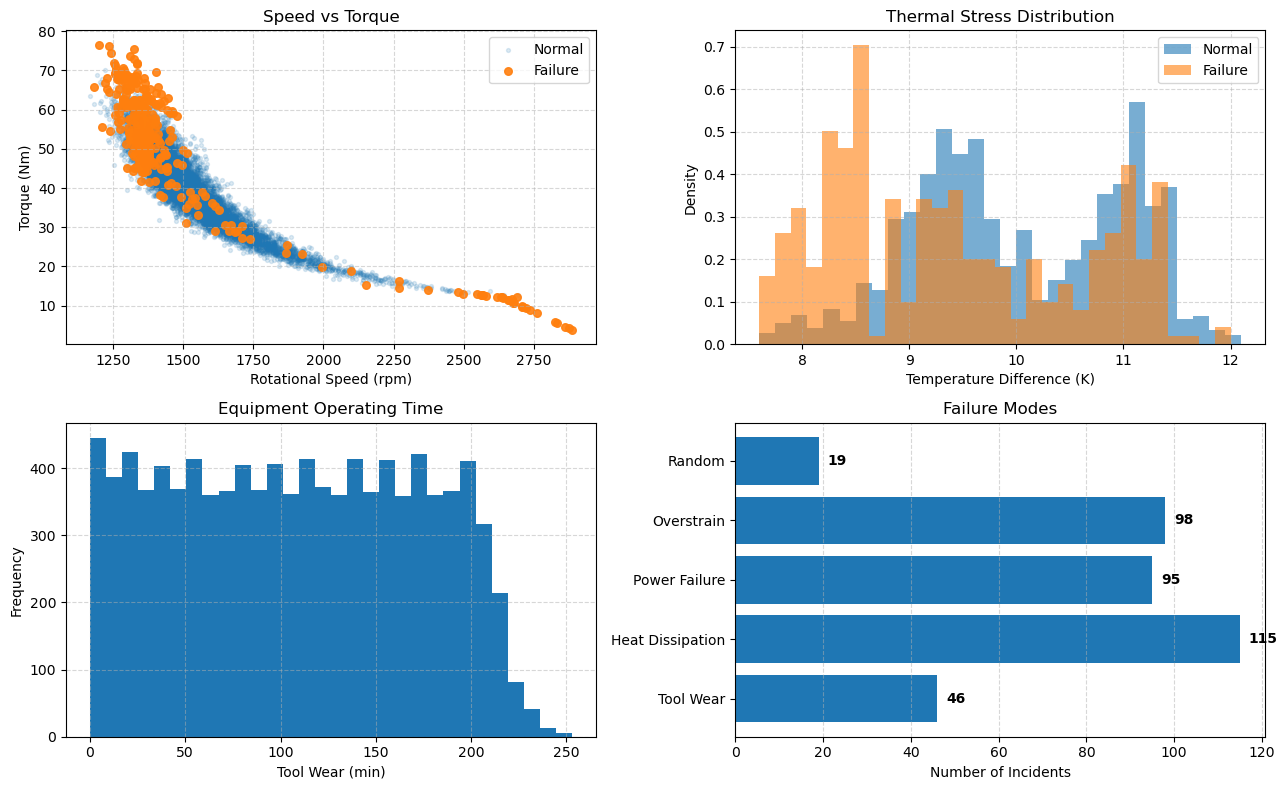

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

normal = df[df.machine_failure == 0]
failed = df[df.machine_failure == 1]

# Speed vs Torque
axes[0,0].scatter(normal.rotational_speed_rpm, normal.torque_nm, alpha=.15, s=8, label='Normal')
axes[0,0].scatter(failed.rotational_speed_rpm, failed.torque_nm, alpha=.9, s=30, label='Failure')
axes[0,0].set(xlabel='Rotational Speed (rpm)', ylabel='Torque (Nm)',
              title='Speed vs Torque')
axes[0,0].legend(); axes[0,0].grid(ls='--', alpha=.5)

# Temperature difference
dT = df.process_temp_k - df.air_temp_k
for val, label in [(0, 'Normal'), (1, 'Failure')]:
    axes[0,1].hist(dT[df.machine_failure == val], bins=30, alpha=.6,
                   density=True, label=label)
axes[0,1].set(xlabel='Temperature Difference (K)', ylabel='Density',
              title='Thermal Stress Distribution')
axes[0,1].legend(); axes[0,1].grid(ls='--', alpha=.5)

# Tool wear
axes[1,0].hist(df.tool_wear_min, bins=30)
axes[1,0].set(xlabel='Tool Wear (min)', ylabel='Frequency',
              title='Equipment Operating Time')
axes[1,0].grid(ls='--', alpha=.5)

# Failure modes
modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
labels = ['Tool Wear', 'Heat Dissipation', 'Power Failure', 'Overstrain', 'Random']
counts = df[modes].sum()
axes[1,1].barh(labels, counts)
for i, v in enumerate(counts):
    axes[1,1].text(v + 2, i, str(v), va='center', fontweight='bold')
axes[1,1].set(xlabel='Number of Incidents', title='Failure Modes')
axes[1,1].grid(axis='x', ls='--', alpha=.5)

plt.tight_layout()
plt.show()

### Correlation Matrix 

<Axes: >

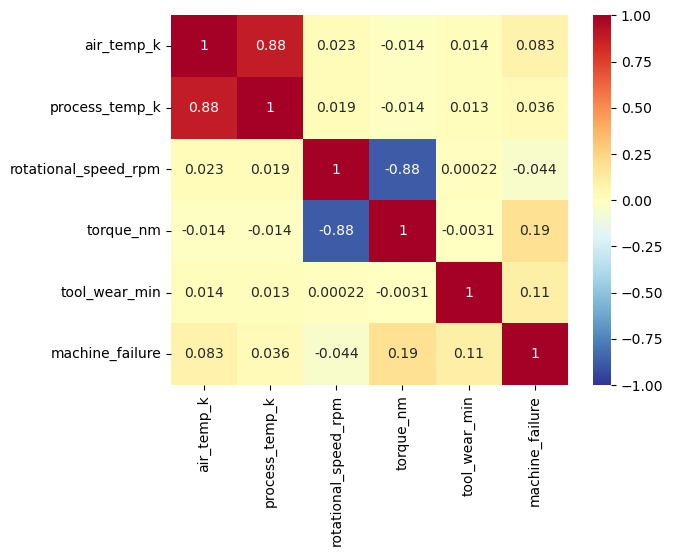

In [6]:
import seaborn as sns
sns.heatmap(df[features + ['tool_wear_min', 'machine_failure']].corr(), annot=True, cmap='RdYlBu_r', vmin=-1, vmax=1)

## Train & Validate Machine Learning Models

We train and benchmark predictive models for:
1. **Mechanical Power & Torque Load Prediction** (Regression: Linear Regression, Random Forest, XGBoost)
2. **Equipment Early Failure Risk** (Classification:XGBoost)

In [7]:
X = df[['air_temp_k', 'process_temp_k', 'rotational_speed_rpm', 'tool_wear_min']]
y = df['torque_nm']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })

results_df = pd.DataFrame(results)
results_df

,Model,R2,MAE,RMSE
0,Linear Regression,0.756591,3.686211,4.897887
1,Random Forest,0.825066,3.114578,4.152193
2,XGBoost,0.833547,3.034791,4.050283


In [8]:
predictions = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred

    results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })

results_df = pd.DataFrame(results)

## Parity Plot: Actual vs. Predicted Equipment Load

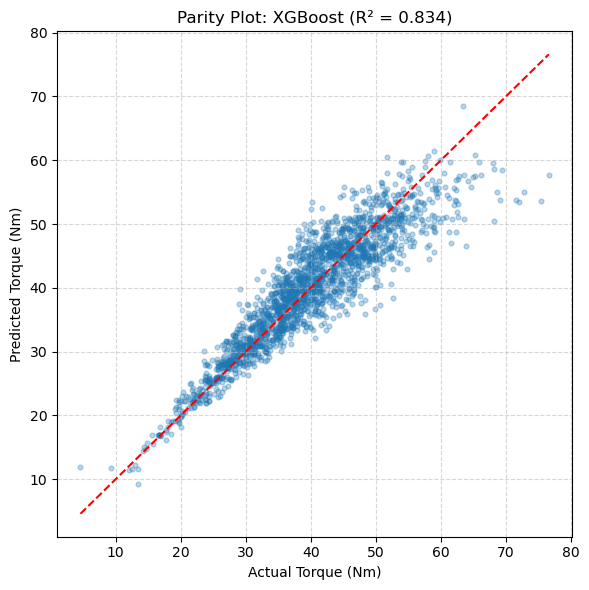

In [9]:
best = results_df.loc[results_df['R2'].idxmax()]
preds = predictions[best['Model']]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=.3, s=12)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Torque (Nm)')
plt.ylabel('Predicted Torque (Nm)')
plt.title(f"Parity Plot: {best['Model']} (R² = {best['R2']:.3f})")
plt.grid(ls='--', alpha=.5)
plt.tight_layout()
plt.show()

## Early Machine Breakdown Classifier (Predictive Maintenance)

In [10]:
X_fail = df[['air_temp_k', 'process_temp_k', 'rotational_speed_rpm',
             'torque_nm', 'tool_wear_min']]
y_fail = df['machine_failure']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_fail, y_fail, test_size=0.2, random_state=42, stratify=y_fail
)

clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

clf.fit(X_tr, y_tr)

y_prob = clf.predict_proba(X_te)[:, 1]
roc_auc = roc_auc_score(y_te, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")
print(classification_report(
    y_te, (y_prob > 0.35).astype(int),
    target_names=['Normal', 'Failure']
))

ROC-AUC: 0.9734


NameError: name 'classification_report' is not defined

## Process Parameter Influence Ranking 

Identifies which operating parameters contribute most to mechanical stress and breakdowns.

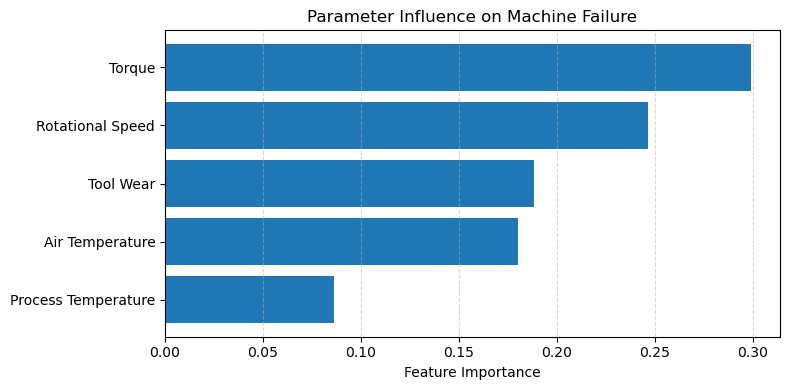

Torque                 0.298906
Rotational Speed       0.246428
Tool Wear              0.188400
Air Temperature        0.180132
Process Temperature    0.086134
dtype: float32


In [ ]:
importance = clf.feature_importances_
names = ['Air Temperature', 'Process Temperature', 'Rotational Speed', 'Torque', 'Tool Wear']
idx = np.argsort(importance)

plt.figure(figsize=(8, 4))
plt.barh(range(len(idx)), importance[idx])
plt.yticks(range(len(idx)), [names[i] for i in idx])
plt.xlabel('Feature Importance')
plt.title('Parameter Influence on Machine Failure')
plt.grid(axis='x', ls='--', alpha=.5)
plt.tight_layout()
plt.show()

print(pd.Series(importance, index=names).sort_values(ascending=False))


A lightweight diagnostic function enabling plant engineers and operators to test operating settings in real-time before applying them on the machine.

In [ ]:
def check_machine_health(speed_rpm, torque_nm, tool_wear_min=100,
                         air_temp_k=300, proc_temp_k=310):

    inp = pd.DataFrame(
        [[air_temp_k, proc_temp_k, speed_rpm, torque_nm, tool_wear_min]],
        columns=X_fail.columns
    )
    risk = clf.predict_proba(inp)[0, 1]

    if risk < 0.05:
        status, action = 'GREEN', 'Continue operation'
    elif risk < 0.25:
        status, action = 'ORANGE', 'Reduce load and inspect lubrication'
    else:
        status, action = 'RED', 'Reduce load and schedule maintenance'

    return risk, status, action


scenarios = [
    ('Standard Operation', 1500, 38, 80), 
    ('High Speed Finish', 2000, 25, 120),
    ('Heavy Load Stress', 1300, 65, 210),
    ('Severe Overload', 2600, 68, 240)
]

results = []
for name, speed, torque, wear in scenarios:
    risk, status, action = check_machine_health(speed, torque, wear)
    results.append([name, f'{risk*100:.1f}%', status, action])

diag_df = pd.DataFrame(
    results,
    columns=['Condition', 'Failure Probability', 'Status', 'Recommended Action']
)

diag_df

,Condition,Failure Probability,Status,Recommended Action
0,Standard Operation,0.1%,GREEN,Continue operation
1,High Speed Finish,0.1%,GREEN,Continue operation
2,Heavy Load Stress,98.0%,RED,Reduce load and schedule maintenance
3,Severe Overload,99.9%,RED,Reduce load and schedule maintenance
